In [1]:
import os
import numpy as np

def return_list(files, pattern_list): # only if all
    file_list = files
    for pattern in pattern_list:
        file_list = [f for f in file_list if pattern in f]
        #file_list.extend([f for f in files if pattern in f])
    return file_list

def extract_episode_number(filename):
    return int((filename.split('_')[-2])[:])

def return_action_dicts(model_step, folder_name): 
    files = os.listdir(folder_name)
    sorted_ep = sorted(return_list(files, [f"model_{model_step}_", "action_dict"]), key=extract_episode_number)
    all_data = []
    for s in sorted_ep[:]:
        file = s
        data = np.load(os.path.join(folder_name, file), allow_pickle=True)
        all_data.append(data)

    # flatten all_data
    #if(len(all_data) > 0):
    #    all_data = np.concatenate(all_data, axis=0)

    return all_data

def return_all_actions(folder_name, model_step): 
    a = return_action_dicts(model_step, folder_name)
    all_actions = dict()
    for it in a:
        actions_dict = it.item()
        for key in actions_dict.keys():
            if key not in all_actions:
                all_actions[key] = []
            all_actions[key].extend(actions_dict[key])
    all_actions = {k: np.array(v) for k, v in all_actions.items()}
    return all_actions

def return_action_magnitude_stats(all_actions):
    avga = []
    stda = []
    mediana = []
    for step in all_actions.keys():
        actions_array = all_actions[step]
        # average action magnitude for each step
        avg_action_magnitude = np.mean(np.linalg.norm(actions_array, axis=1))
        #print(f"Step {step}: Average Action Magnitude = {avg_action_magnitude}")
        avga.append(avg_action_magnitude)
        stda.append(np.std(np.linalg.norm(actions_array, axis=1)))
        mediana.append(np.median(np.linalg.norm(actions_array, axis=1)))
    return np.array(avga), np.array(stda), np.array(mediana)


In [2]:
all_actions_gb1 = return_all_actions("models_gb1", 400000)
all_actions_ubq = return_all_actions("models_ubq", 400000)
all_actions_dfr = return_all_actions("models_dfr", 400000)

In [3]:
avga_gb1, stda_gb1, mediana_gb1 = return_action_magnitude_stats(all_actions_gb1)
avga_ubq, stda_ubq, mediana_ubq = return_action_magnitude_stats(all_actions_ubq)
avga_dfr, stda_dfr, mediana_dfr = return_action_magnitude_stats(all_actions_dfr)

steps = np.arange(0, len(avga_gb1))


In [4]:
def return_final_angles(model_step, folder_name): 
    files = os.listdir(folder_name)
    sorted_ep = sorted(return_list(files, [f"model_{model_step}_", "final"]), key=extract_episode_number)

    all_data = []
    for s in sorted_ep[:]:
        file = s
        data = np.load(os.path.join(folder_name, file)) #, allow_pickle=True)
        all_data.append(data)

    # flatten all_data
    if(len(all_data) > 0):
        all_data = np.concatenate(all_data, axis=0)

    return all_data

def store_final_angle_dict(folder_name, model_names): 
    files = os.listdir(folder_name)
    files_filtered = [f for f in files if f.startswith(f"results_final_")]
    final_angles = {}
    for i in range(len(model_names)):
        model_step = model_names[i]
        #print(f"Model step: {model_step}")
        a = return_final_angles(model_step, folder_name)
        final_angles[model_step] = a
    return final_angles




In [5]:
mod_names = [1000, 5000, 10000, 15000, 20000, 40000, 60000, 100000, 200000, 400000]
final_angles_ubq = store_final_angle_dict("models_ubq", mod_names)
final_angles_gb1 = store_final_angle_dict("models_gb1", mod_names)
final_angles_dfr = store_final_angle_dict("models_dfr", mod_names)

In [6]:

def ret_succes(final_angles): 
    final_angles = dict(sorted(final_angles.items()))
    final_angles = {k: np.array(v) for k, v in final_angles.items()}
    succes = []
    std_final = []
    mean_final = []
    for step in final_angles.keys():
        angles_array = final_angles[step]
        # average action magnitude for each step
        # count number of angles lower than 0.1 
        mean_final.append(np.mean(angles_array)/np.pi*180)
        std_final.append(np.std(angles_array)/np.pi*180)
        cnt = np.sum(angles_array < 20/180*np.pi)
        print(f"Step {step}: Number of angles < 0.1 = {cnt/len(angles_array)}")
        succes.append(cnt/len(angles_array))
    return succes, std_final, mean_final

succes_ubq, std_final_ubq, mean_final_ubq = ret_succes(final_angles_ubq)
succes_gb1, std_final_gb1, mean_final_gb1 = ret_succes(final_angles_gb1)
succes_dfr, std_final_dfr, mean_final_dfr = ret_succes(final_angles_dfr)

Step 1000: Number of angles < 0.1 = 0.00625
Step 5000: Number of angles < 0.1 = 0.3625
Step 10000: Number of angles < 0.1 = 0.5765625
Step 15000: Number of angles < 0.1 = 0.7
Step 20000: Number of angles < 0.1 = 0.7359375
Step 40000: Number of angles < 0.1 = 0.853125
Step 60000: Number of angles < 0.1 = 0.8640625
Step 100000: Number of angles < 0.1 = 0.903125
Step 200000: Number of angles < 0.1 = 0.9234375
Step 400000: Number of angles < 0.1 = 0.93125
Step 1000: Number of angles < 0.1 = 0.003125
Step 5000: Number of angles < 0.1 = 0.2296875
Step 10000: Number of angles < 0.1 = 0.5171875
Step 15000: Number of angles < 0.1 = 0.634375
Step 20000: Number of angles < 0.1 = 0.6734375
Step 40000: Number of angles < 0.1 = 0.8625
Step 60000: Number of angles < 0.1 = 0.878125
Step 100000: Number of angles < 0.1 = 0.9453125
Step 200000: Number of angles < 0.1 = 0.9765625
Step 400000: Number of angles < 0.1 = 0.9890625
Step 1000: Number of angles < 0.1 = 0.002
Step 5000: Number of angles < 0.1 = 0

In [7]:
def read_combined_rg_csv(filename):
    """
    Read a combined radius-of-gyration CSV file.

    Expected columns:
        eval, frame, timestep, radius_of_gyration

    Returns
    -------
    results : dict
        Dictionary keyed by evaluation number.

        Example:
            results[0]["frame"]
            results[0]["timestep"]
            results[0]["rg"]
    """

    data = np.genfromtxt(
        filename,
        delimiter=",",
        names=True
    )

    results = {}

    eval_numbers = np.unique(data["eval"]).astype(int)

    for eval_number in eval_numbers:

        mask = data["eval"] == eval_number

        results[eval_number] = {
            "frame": data["frame"][mask].astype(int),
            "timestep": data["timestep"][mask].astype(int),
            "rg": data["radius_of_gyration"][mask]
        }

    return results

results = read_combined_rg_csv("all_evals_rg.csv")

OSError: [Errno 107] Transport endpoint is not connected

In [9]:
# average over results and calculate mean and std
import numpy as np

res_avg = np.mean([results[eval_number]["rg"] for eval_number in results.keys()], axis=0)
res_std = np.std([results[eval_number]["rg"] for eval_number in results.keys()], axis=0)

In [53]:
len(res_avg)

1530

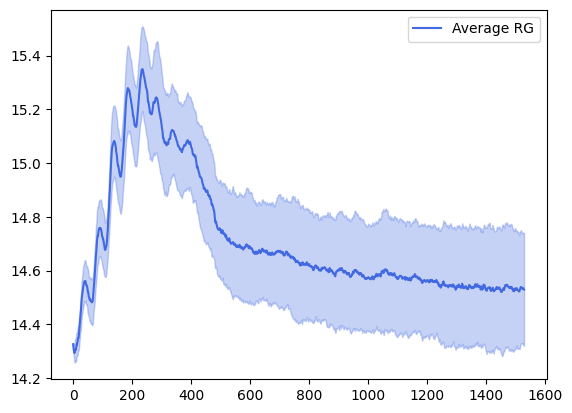

In [10]:
import matplotlib.pyplot as plt
# fill plot instead of errorbar

plt.fill_between(
    np.arange(len(res_avg)),
    res_avg - res_std,
    res_avg + res_std,
    alpha=0.3,
    color="royalblue"
)

plt.plot(
    np.arange(len(res_avg)),
    res_avg,
    color="royalblue",
    label="Average RG"
)

plt.legend()

In [7]:
import csv


def read_combined_csv(filename):
    """
    Read the combined Kabsch CSV.

    Returns
    -------
    data : list of lists

        data[eval][frame] = [
            timestep,
            angle_rad,
            angle_deg
        ]
    """

    data = []

    with open(filename, "r", newline="") as f:

        reader = csv.DictReader(f)

        for row in reader:

            # Convert "eval_0" -> 0
            eval_number = int(
                row["eval"].split("_")[1]
            )

            frame = int(row["frame"])
            timestep = int(row["timestep"])
            angle_rad = float(
                row["kabsch_angle_rad"]
            )
            angle_deg = float(
                row["kabsch_angle_deg"]
            )

            # Create lists for evaluations that
            # have not been encountered yet
            while len(data) <= eval_number:
                data.append([])

            # Store:
            # [timestep, angle_rad, angle_deg]
            data[eval_number].append([
                timestep,
                angle_rad,
                angle_deg
            ])

    return data

data = read_combined_csv("kabsch_angles_all.csv")

In [8]:
data = np.array(data, dtype=float) # Convert to a regular NumPy array

ang_mean = np.mean(data[:,:,2], axis=0)
ang_std = np.std(data[:,:,2], axis=0)


In [9]:
import csv


def read_combined_csv_rmsd(filename):
    """
    Read the combined Kabsch CSV.

    Returns
    -------
    data : list of lists

        data[eval][frame] = [
            timestep,
            angle_rad,
            angle_deg
        ]
    """

    data = []

    with open(filename, "r", newline="") as f:

        reader = csv.DictReader(f)

        for row in reader:

            # Convert "eval_0" -> 0
            eval_number = int(
                row["eval"].split("_")[1]
            )

            frame = int(row["frame"])
            timestep = int(row["timestep"])
            rmsd = float(
                row["rmsd"]
            )

            # Create lists for evaluations that
            # have not been encountered yet
            while len(data) <= eval_number:
                data.append([])

            # Store:
            # [timestep, rmsd, angle_deg]
            data[eval_number].append([
                timestep,
                rmsd
            ])

    return data

data = read_combined_csv_rmsd("rmsd_all.csv")

In [10]:
data = np.array(data, dtype=float) # Convert to a regular NumPy array
data_mean = np.mean(data[:,:,1], axis=0)
data_std = np.std(data[:,:,1], axis=0)


def return_all_actions(folder_name, model_step): 
    a = return_action_dicts(model_step, folder_name)
    all_actions = dict()
    for it in a:
        actions_dict = it.item()
        for key in actions_dict.keys():
            if key not in all_actions:
                all_actions[key] = []
            all_actions[key].extend(actions_dict[key])
    all_actions = {k: np.array(v) for k, v in all_actions.items()}
    return all_actions
all_actions_dhfr = return_all_actions("models", 400000)

act = []
act_std = []
step = []

for i in range(30):
    avg = np.mean(all_actions_dhfr[i], axis=0)
    std = np.std(all_actions_dhfr[i], axis=0)
    act.append(avg)
    act_std.append(std)
    step.append(i)


act = np.array(act)
act_std = np.array(act_std)
step = np.array(step)

In [11]:

def return_all_actions(folder_name, model_step): 
    a = return_action_dicts(model_step, folder_name)
    all_actions = dict()
    for it in a:
        actions_dict = it.item()
        for key in actions_dict.keys():
            if key not in all_actions:
                all_actions[key] = []
            all_actions[key].extend(actions_dict[key])
    all_actions = {k: np.array(v) for k, v in all_actions.items()}
    return all_actions
all_actions_dhfr = return_all_actions("models", 400000)

/tmp/ipykernel_3921394/2521041737.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


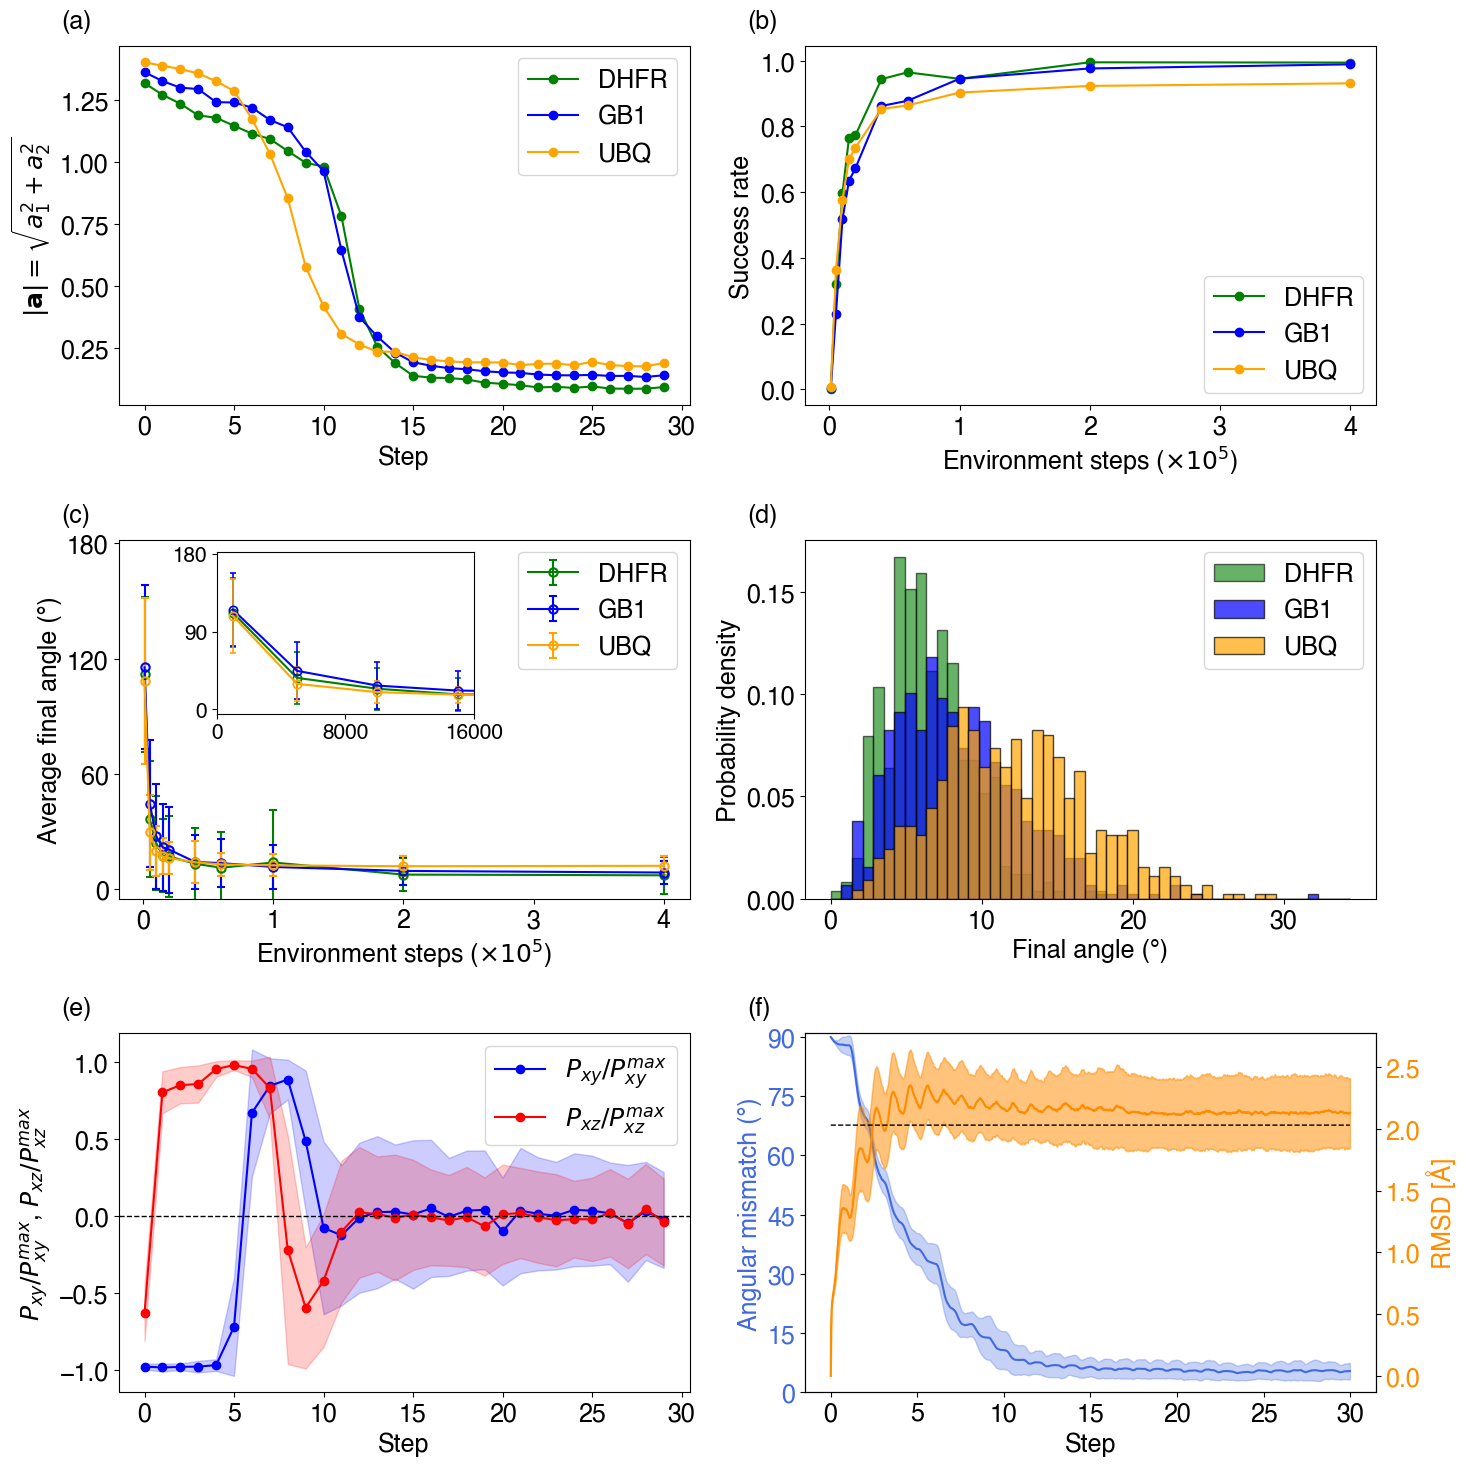

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import os

font_dir = os.path.expanduser("~/.local/share/fonts")
fm.fontManager.addfont(os.path.join(font_dir, "Helvetica.ttf"))

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 18,
    "axes.labelsize": 18
})


# Create two subplots in one row
fig, ax = plt.subplots(3, 2, figsize=(15, 15))



steps = np.arange(0, len(avga_gb1))


ax[0,0].plot(steps,mediana_dfr,label="DHFR",marker="o",color="green")
ax[0,0].plot(steps,mediana_gb1,label="GB1",marker="o",color="blue")
ax[0,0].plot(steps,mediana_ubq,label="UBQ",marker="o",color="orange")
ax[0,0].set_xlabel("Step")
ax[0,0].set_ylabel(r"$|\mathbf{a}|=\sqrt{a_1^2+a_2^2}$")
ax[0,0].legend()
#ax[0].grid(alpha=0.3)

# ---------------- Right subplot ----------------

ax[0,1].plot(np.array(list(final_angles_dfr.keys()))/100000,succes_dfr,marker="o",color="green", label="DHFR")
ax[0,1].plot(np.array(list(final_angles_gb1.keys()))/100000,succes_gb1,marker="o",color="blue", label="GB1")
ax[0,1].plot(np.array(list(final_angles_ubq.keys()))/100000,succes_ubq,marker="o",color="orange", label="UBQ")
ax[0,1].set_xlabel("Environment steps ($\\times 10^5$)")
ax[0,1].set_ylabel("Success rate")
ax[0,1].legend()

ax[0,0].text(-0.1, 1.05, "(a)", transform=ax[0,0].transAxes, fontsize=18, fontweight='bold')
ax[0,1].text(-0.1, 1.05, "(b)", transform=ax[0,1].transAxes, fontsize=18, fontweight='bold')
ax[1,0].text(-0.1, 1.05, "(c)", transform=ax[1,0].transAxes, fontsize=18, fontweight='bold')
ax[1,1].text(-0.1, 1.05, "(d)", transform=ax[1,1].transAxes, fontsize=18, fontweight='bold')


ax[1,0].errorbar(np.array(list(final_angles_dfr.keys()))/100000, mean_final_dfr, yerr=std_final_dfr, fmt='-o', color='green', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="DHFR")
ax[1,0].errorbar(np.array(list(final_angles_gb1.keys()))/100000, mean_final_gb1, yerr=std_final_gb1, fmt='-o', color='blue', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="GB1")
ax[1,0].errorbar(np.array(list(final_angles_ubq.keys()))/100000, mean_final_ubq, yerr=std_final_ubq, fmt='-o', color='orange', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="UBQ")

ax[1,0].set_ylabel("Average final angle (°)")
ax[1,0].set_xlabel("Environment steps ($\\times 10^5$)")
ax[1,0].legend()
ax[1,0].tick_params(axis="y")
ax[1,0].set_ylim(-5,182)
#ax[1,0].set_xlim(-1,400000)
ax[1,0].set_yticks([0, 60, 120, 180])


# ------------------------------------------------------------------
# Inset
# ------------------------------------------------------------------
axins = inset_axes(
    ax[1,0],
    width="45%",
    height="45%",
    loc="upper left",
    bbox_to_anchor=(0.15, 0.0, 1, 1),   # increase first value to move right
    bbox_transform=ax[1,0].transAxes,
)

# Replot data in inset
axins.errorbar(np.array(list(final_angles_dfr.keys())), mean_final_dfr,
               yerr=std_final_dfr, fmt='-o', color='green',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)

axins.errorbar(np.array(list(final_angles_gb1.keys())), mean_final_gb1,
               yerr=std_final_gb1, fmt='-o', color='blue',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)

axins.errorbar(np.array(list(final_angles_ubq.keys())), mean_final_ubq,
               yerr=std_final_ubq, fmt='-o', color='orange',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)


# Zoom region
axins.set_xlim(0, 16000)
axins.set_ylim(-5, 182)
axins.set_xticks([0, 8000, 16000])
axins.set_yticks([0, 90, 180])
axins.tick_params(labelsize=15)

# Draw box on main axes and connect to inset
#mark_inset(ax[1,0], axins, loc1=2, loc2=4, fc="none", ec="0.5")





angles_ubq = final_angles_ubq[400000]
angles_gb1 = final_angles_gb1[400000]
angles_dfr = final_angles_dfr[400000]
rad_to_deg = 180/np.pi
bins = np.linspace(0, 0.6*rad_to_deg, 50)


ax[1,1].hist(angles_dfr/np.pi*180, bins=bins, ec = 'black', density=True, color='green', alpha=0.6, label='DHFR')
ax[1,1].hist(angles_gb1/np.pi*180, bins=bins, ec = 'black', density=True, color='blue', alpha=0.7, label='GB1')
ax[1,1].hist(angles_ubq/np.pi*180, bins=bins, ec = 'black', density=True, color='orange', alpha=0.7, label='UBQ')
ax[1,1].set_xlabel("Final angle (°)")
ax[1,1].set_ylabel("Probability density")
ax[1,1].legend()



# Action 0
ax[2,0].plot(
    step, act[:, 0],
    '-o',
    color='blue',
    label='$P_{xy}/P_{xy}^{max}$'
)

ax[2,0].fill_between(
    step,
    act[:, 0] - act_std[:, 0],
    act[:, 0] + act_std[:, 0],
    color='blue',
    alpha=0.2
)


# Action 1
ax[2,0].plot(
    step, act[:, 1],
    '-o',
    color='red',
    label='$P_{xz}/P_{xz}^{max}$'
)

ax[2,0].fill_between(
    step,
    act[:, 1] - act_std[:, 1],
    act[:, 1] + act_std[:, 1],
    color='red',
    alpha=0.2
)


ax[2,0].axhline(y=0, color='black', linestyle='--', linewidth=1)

ax[2,0].set_xlabel('Step')
ax[2,0].set_ylabel('$P_{xy}/P_{xy}^{max}$, $P_{xz}/P_{xz}^{max}$')
ax[2,0].legend()

mask = (np.arange(len(ang_mean)) + 1) % 50 != 0

#x = np.arange(len(ang_mean))[mask] / 50
mean = ang_mean[mask]
std = ang_std[mask]
x = np.arange(len(mean)) / 50

# Left y-axis: Kabsch angle
ax[2,1].fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.3,
    color="royalblue"
)

ax[2,1].plot(
    x,
    mean,
    color="royalblue",
    label="Average Kabsch angle"
)

ax[2,1].set_xlabel("Step")
ax[2,1].set_ylabel("Angular mismatch (°)", color="royalblue")
ax[2,1].tick_params(axis="y", labelcolor="royalblue")

ax[2,1].set_ylim(0, 91)
ax[2,1].set_yticks([0, 15, 30, 45, 60, 75, 90])



# Right y-axis: RMSD
ax21_right = ax[2,1].twinx()

mask = (np.arange(len(data_mean)) + 1) % 50 != 0
mean = data_mean[mask]
std = data_std[mask]

x = np.arange(len(mean)) / 50


ax21_right.fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.3,
    color="darkorange"
)

ax21_right.plot(
    x,
    mean,
    color="darkorange"
)

ax21_right.set_ylabel("RMSD [Å]", color="darkorange")
ax21_right.tick_params(axis="y", labelcolor="darkorange")


ax21_right.fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.3,
    color="darkorange"
)

rmsd_eq_loaded = np.load("rmsd_eq_first300.npy")

#plt.plot(5*x[0:len(rmsd_eq_loaded)], rmsd_eq_loaded, color="blue")

mean_rmsd = np.mean(rmsd_eq_loaded)

std_rmsd = np.std(rmsd_eq_loaded)

#ax21_right.axhline(y=mean_rmsd, color="blue", linestyle="--", linewidth=1)
ax21_right.plot(x, mean_rmsd * np.ones_like(x), color="black", linestyle="--", linewidth=1)
#ax21_right.fill_between(
#    x,
#    mean_rmsd - std_rmsd,
#    mean_rmsd + std_rmsd,
#    alpha=0.3,
#   color="blue"
#)

# Combined legend
lines_left, labels_left = ax[2,1].get_legend_handles_labels()
lines_right, labels_right = ax21_right.get_legend_handles_labels()

ax[2,0].text(
    -0.1, 1.05, "(e)",
    transform=ax[2,0].transAxes,
    fontsize=18,
    fontweight='bold'
)
ax[2,1].text(
    -0.1, 1.05, "(f)",
    transform=ax[2,1].transAxes,
    fontsize=18,
    fontweight='bold'
)


# Adjust spacing
plt.tight_layout()

# Save the combined figure
plt.savefig("action_magnitude_and_success_rate.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_794221/3034316390.py:242: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


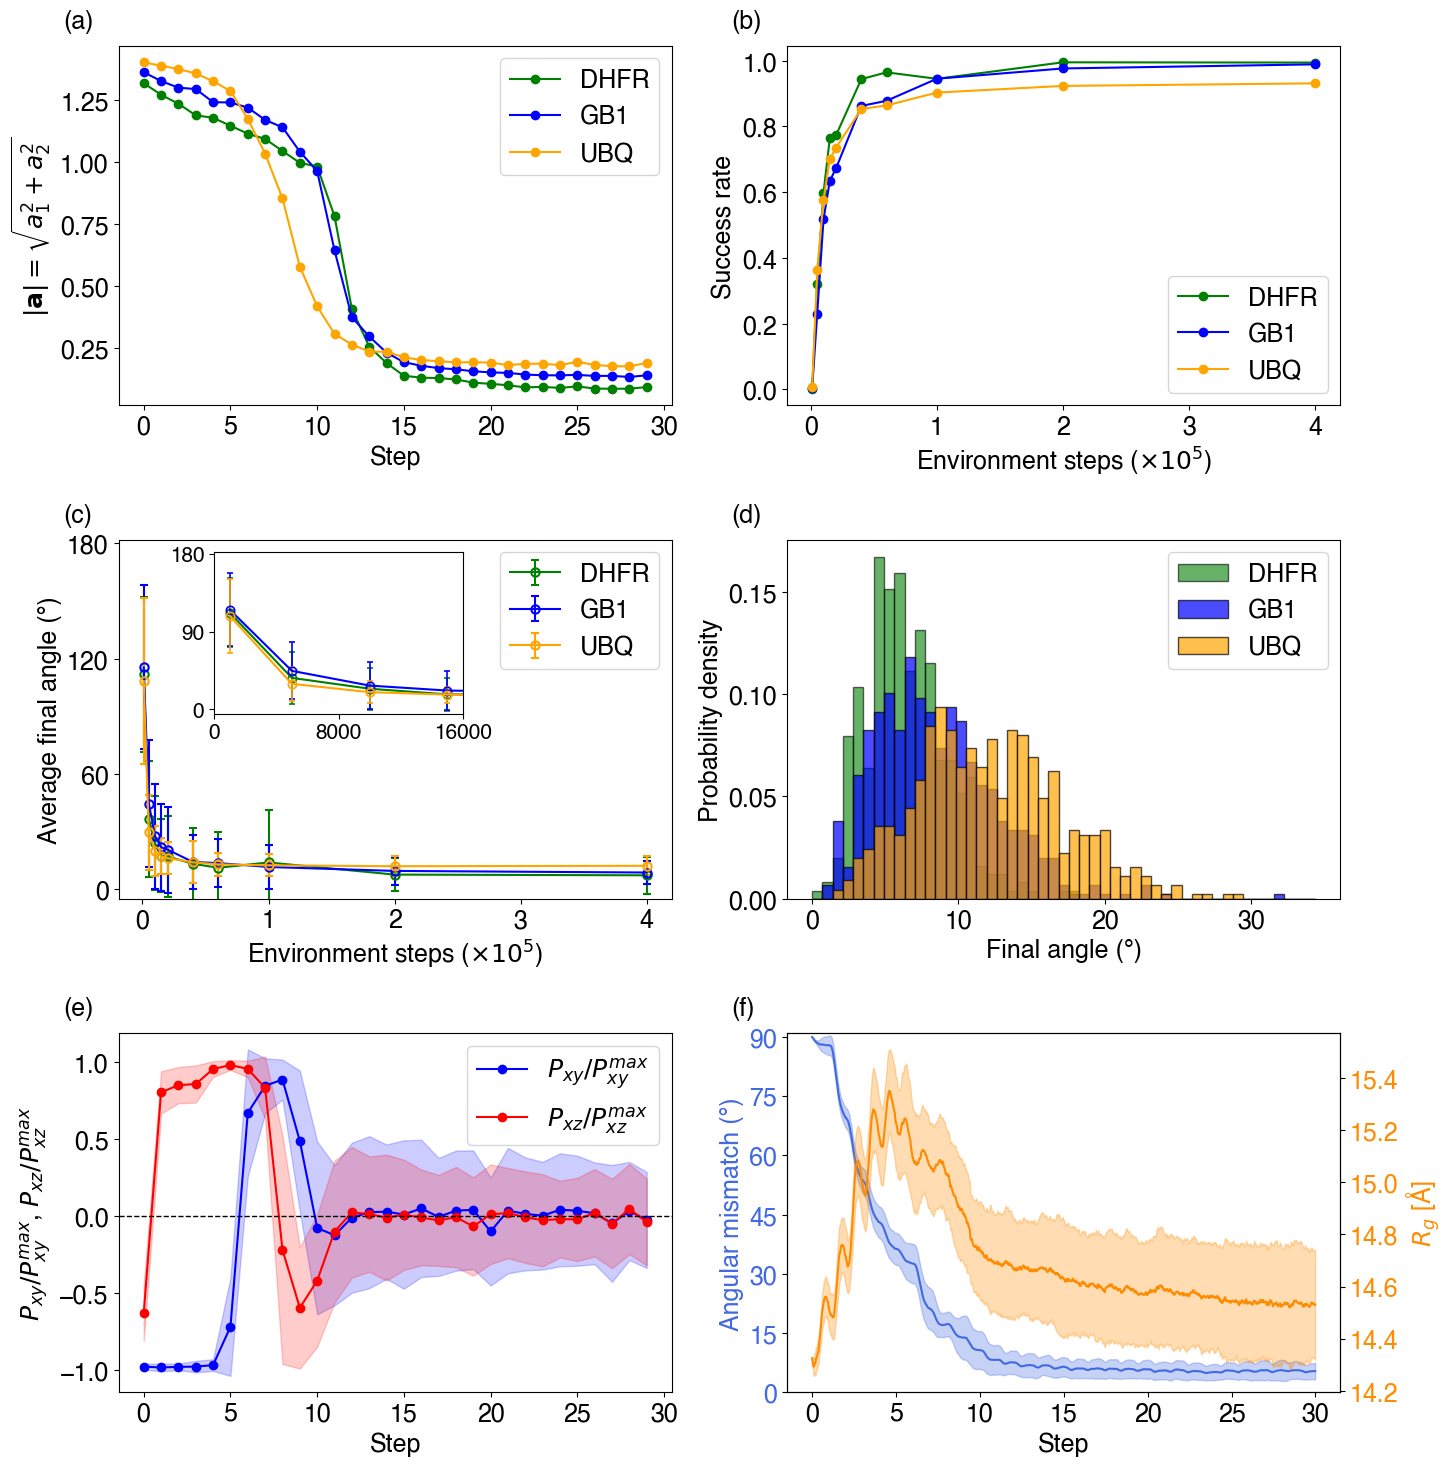

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import os

font_dir = os.path.expanduser("~/.local/share/fonts")
fm.fontManager.addfont(os.path.join(font_dir, "Helvetica.ttf"))

plt.rcParams.update({
    "font.family": "Helvetica",
    "font.size": 18,
    "axes.labelsize": 18
})


# Create two subplots in one row
fig, ax = plt.subplots(3, 2, figsize=(15, 15))



steps = np.arange(0, len(avga_gb1))


ax[0,0].plot(steps,mediana_dfr,label="DHFR",marker="o",color="green")
ax[0,0].plot(steps,mediana_gb1,label="GB1",marker="o",color="blue")
ax[0,0].plot(steps,mediana_ubq,label="UBQ",marker="o",color="orange")
ax[0,0].set_xlabel("Step")
ax[0,0].set_ylabel(r"$|\mathbf{a}|=\sqrt{a_1^2+a_2^2}$")
ax[0,0].legend()
#ax[0].grid(alpha=0.3)

# ---------------- Right subplot ----------------

ax[0,1].plot(np.array(list(final_angles_dfr.keys()))/100000,succes_dfr,marker="o",color="green", label="DHFR")
ax[0,1].plot(np.array(list(final_angles_gb1.keys()))/100000,succes_gb1,marker="o",color="blue", label="GB1")
ax[0,1].plot(np.array(list(final_angles_ubq.keys()))/100000,succes_ubq,marker="o",color="orange", label="UBQ")
ax[0,1].set_xlabel("Environment steps ($\\times 10^5$)")
ax[0,1].set_ylabel("Success rate")
ax[0,1].legend()

ax[0,0].text(-0.1, 1.05, "(a)", transform=ax[0,0].transAxes, fontsize=18, fontweight='bold')
ax[0,1].text(-0.1, 1.05, "(b)", transform=ax[0,1].transAxes, fontsize=18, fontweight='bold')
ax[1,0].text(-0.1, 1.05, "(c)", transform=ax[1,0].transAxes, fontsize=18, fontweight='bold')
ax[1,1].text(-0.1, 1.05, "(d)", transform=ax[1,1].transAxes, fontsize=18, fontweight='bold')


ax[1,0].errorbar(np.array(list(final_angles_dfr.keys()))/100000, mean_final_dfr, yerr=std_final_dfr, fmt='-o', color='green', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="DHFR")
ax[1,0].errorbar(np.array(list(final_angles_gb1.keys()))/100000, mean_final_gb1, yerr=std_final_gb1, fmt='-o', color='blue', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="GB1")
ax[1,0].errorbar(np.array(list(final_angles_ubq.keys()))/100000, mean_final_ubq, yerr=std_final_ubq, fmt='-o', color='orange', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="UBQ")

ax[1,0].set_ylabel("Average final angle (°)")
ax[1,0].set_xlabel("Environment steps ($\\times 10^5$)")
ax[1,0].legend()
ax[1,0].tick_params(axis="y")
ax[1,0].set_ylim(-5,182)
#ax[1,0].set_xlim(-1,400000)
ax[1,0].set_yticks([0, 60, 120, 180])


# ------------------------------------------------------------------
# Inset
# ------------------------------------------------------------------
axins = inset_axes(
    ax[1,0],
    width="45%",
    height="45%",
    loc="upper left",
    bbox_to_anchor=(0.15, 0.0, 1, 1),   # increase first value to move right
    bbox_transform=ax[1,0].transAxes,
)

# Replot data in inset
axins.errorbar(np.array(list(final_angles_dfr.keys())), mean_final_dfr,
               yerr=std_final_dfr, fmt='-o', color='green',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)

axins.errorbar(np.array(list(final_angles_gb1.keys())), mean_final_gb1,
               yerr=std_final_gb1, fmt='-o', color='blue',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)

axins.errorbar(np.array(list(final_angles_ubq.keys())), mean_final_ubq,
               yerr=std_final_ubq, fmt='-o', color='orange',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)


# Zoom region
axins.set_xlim(0, 16000)
axins.set_ylim(-5, 182)
axins.set_xticks([0, 8000, 16000])
axins.set_yticks([0, 90, 180])
axins.tick_params(labelsize=15)

# Draw box on main axes and connect to inset
#mark_inset(ax[1,0], axins, loc1=2, loc2=4, fc="none", ec="0.5")





angles_ubq = final_angles_ubq[400000]
angles_gb1 = final_angles_gb1[400000]
angles_dfr = final_angles_dfr[400000]
rad_to_deg = 180/np.pi
bins = np.linspace(0, 0.6*rad_to_deg, 50)


ax[1,1].hist(angles_dfr/np.pi*180, bins=bins, ec = 'black', density=True, color='green', alpha=0.6, label='DHFR')
ax[1,1].hist(angles_gb1/np.pi*180, bins=bins, ec = 'black', density=True, color='blue', alpha=0.7, label='GB1')
ax[1,1].hist(angles_ubq/np.pi*180, bins=bins, ec = 'black', density=True, color='orange', alpha=0.7, label='UBQ')
ax[1,1].set_xlabel("Final angle (°)")
ax[1,1].set_ylabel("Probability density")
ax[1,1].legend()



# Action 0
ax[2,0].plot(
    step, act[:, 0],
    '-o',
    color='blue',
    label='$P_{xy}/P_{xy}^{max}$'
)

ax[2,0].fill_between(
    step,
    act[:, 0] - act_std[:, 0],
    act[:, 0] + act_std[:, 0],
    color='blue',
    alpha=0.2
)


# Action 1
ax[2,0].plot(
    step, act[:, 1],
    '-o',
    color='red',
    label='$P_{xz}/P_{xz}^{max}$'
)

ax[2,0].fill_between(
    step,
    act[:, 1] - act_std[:, 1],
    act[:, 1] + act_std[:, 1],
    color='red',
    alpha=0.2
)


ax[2,0].axhline(y=0, color='black', linestyle='--', linewidth=1)

ax[2,0].set_xlabel('Step')
ax[2,0].set_ylabel('$P_{xy}/P_{xy}^{max}$, $P_{xz}/P_{xz}^{max}$')
ax[2,0].legend()

mask = (np.arange(len(ang_mean)) + 1) % 50 != 0

#x = np.arange(len(ang_mean))[mask] / 50
mean = ang_mean[mask]
std = ang_std[mask]
x = np.arange(len(mean)) / 50

# Left y-axis: Kabsch angle
ax[2,1].fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.3,
    color="royalblue"
)

ax[2,1].plot(
    x,
    mean,
    color="royalblue",
    label="Average Kabsch angle"
)

ax[2,1].set_xlabel("Step")
ax[2,1].set_ylabel("Angular mismatch (°)", color="royalblue")
ax[2,1].tick_params(axis="y", labelcolor="royalblue")

ax[2,1].set_ylim(0, 91)
ax[2,1].set_yticks([0, 15, 30, 45, 60, 75, 90])


# Right y-axis: RMSD
ax21_right = ax[2,1].twinx()

mask = (np.arange(len(res_avg)) + 1) % 50 != 0



mean = res_avg[mask]
std = res_std[mask]

x = np.arange(len(mean)) / 50


ax21_right.fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.3,
    color="darkorange"
)

ax21_right.plot(
    x,
    mean,
    color="darkorange"
)

ax21_right.set_ylabel("$R_g$ [Å]", color="darkorange")
ax21_right.tick_params(axis="y", labelcolor="darkorange")


# Combined legend
lines_left, labels_left = ax[2,1].get_legend_handles_labels()
lines_right, labels_right = ax21_right.get_legend_handles_labels()

ax[2,0].text(
    -0.1, 1.05, "(e)",
    transform=ax[2,0].transAxes,
    fontsize=18,
    fontweight='bold'
)
ax[2,1].text(
    -0.1, 1.05, "(f)",
    transform=ax[2,1].transAxes,
    fontsize=18,
    fontweight='bold'
)


# Adjust spacing
plt.tight_layout()

# Save the combined figure
plt.savefig("action_magnitude_and_success_rate_b.png", dpi=300, bbox_inches="tight")

plt.show()

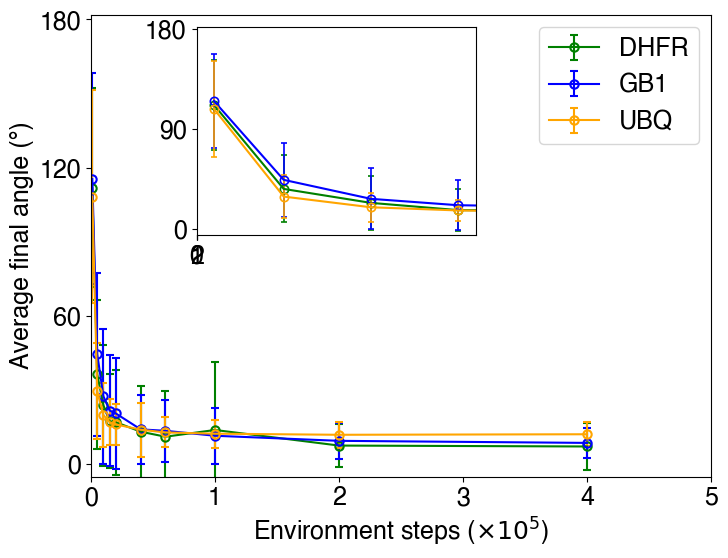

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(np.array(list(final_angles_dfr.keys()))/100000, mean_final_dfr, yerr=std_final_dfr, fmt='-o', color='green', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="DHFR")
ax.errorbar(np.array(list(final_angles_gb1.keys()))/100000, mean_final_gb1, yerr=std_final_gb1, fmt='-o', color='blue', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="GB1")
ax.errorbar(np.array(list(final_angles_ubq.keys()))/100000, mean_final_ubq, yerr=std_final_ubq, fmt='-o', color='orange', elinewidth=1.5, capsize=3, markerfacecolor='none', markeredgewidth=1.5, label="UBQ")

ax.set_ylabel("Average final angle (°)")
ax.set_xlabel("Environment steps ($\\times 10^5$)")
ax.legend()
ax.tick_params(axis="y")
ax.set_ylim(-5,182)
ax.set_xlim(0,5)
ax.set_yticks([0, 60, 120, 180])


# ------------------------------------------------------------------
# Inset
# ------------------------------------------------------------------
axins = inset_axes(
    ax,
    width="45%",
    height="45%",
    loc="upper left",
    bbox_to_anchor=(0.15, 0.0, 1, 1),   # increase first value to move right
    bbox_transform=ax.transAxes,
)

# Replot data in inset
axins.errorbar(np.array(list(final_angles_dfr.keys())), mean_final_dfr,
               yerr=std_final_dfr, fmt='-o', color='green',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)

axins.errorbar(np.array(list(final_angles_gb1.keys())), mean_final_gb1,
               yerr=std_final_gb1, fmt='-o', color='blue',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)

axins.errorbar(np.array(list(final_angles_ubq.keys())), mean_final_ubq,
               yerr=std_final_ubq, fmt='-o', color='orange',
               elinewidth=1.2, capsize=2, markerfacecolor='none',
               markeredgewidth=1.2)


# Zoom region
axins.set_xlim(0, 16000)
axins.set_ylim(-5, 182)
axins.set_xticks([0, 1, 2])
axins.set_yticks([0, 90, 180])
#axins.tick_params(labelsize=15)

# Draw box on main axes and connect to inset
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")



In [31]:
x = np.arange(len(ang_mean))[mask] / 50
mean = ang_mean[mask]
std = ang_std[mask]

In [ ]:
np.arange(len(ang_mean)

array([0.000e+00, 2.000e-02, 4.000e-02, ..., 3.054e+01, 3.056e+01,
       3.058e+01])

In [33]:
ang_mean

array([90.        , 89.88197198, 89.75627381, ...,  5.33645958,
        5.35167142,  5.36040392])